In [ ]:
#http://127.0.0.1:8888/?token=641ff58c730676d8f40d01ea1af56b3dc8e8be248d9aeb4a
import os
import re
import pandas as pd
import operator
import matplotlib.pyplot as plt
import warnings
import gensim
import numpy as np
from pprint import pprint
import json

import pyLDAvis.gensim
import datetime
# NLTK
import nltk
from nltk.stem.lancaster import LancasterStemmer
from nltk.corpus import stopwords
from nltk.stem.porter import *
from nltk import word_tokenize

import numpy as np
import string
import pandas as pd

from pprint import pprint

# Gensim
import gensim
from gensim.models import CoherenceModel, LdaModel, LsiModel, HdpModel
from gensim.corpora import Dictionary
import gensim.corpora as corpora
from gensim.utils import simple_preprocess

# Plotting tools
import pyLDAvis
import pyLDAvis.gensim  # don't skip this
import matplotlib.pyplot as plt

# Enable logging for gensim - optional
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.ERROR)

import warnings
warnings.filterwarnings("ignore",category=DeprecationWarning)

%matplotlib inline

In [ ]:
# import file in order to calculate LDA
filename = 'libra_messages_subreddit_libra.csv'
df = pd.read_csv(os.path.join(os.getcwd(), 'reddit_data', 'clean_data', filename))
# df = df[len(df)-50:]
print(len(df))

# STOPWORDS

In [ ]:
stop_words = stopwords.words('english')
stop_words.extend(['from', 'subject', 're', 'edu', 'use', 'ive', 'youre'])

In [ ]:
# Convert to list
data = df.body.values.tolist()

# Remove Emails
data = [re.sub('\S*@\S*\s?', '', sent) for sent in data]

# Remove new line characters
data = [re.sub('\s+', ' ', sent) for sent in data]

# Remove distracting single quotes
data = [re.sub("\'", "", sent) for sent in data]

# Remove hyperlinks
data = [re.sub(r'http\S+', '', sent) for sent in data]

pprint(data[:1])

# Tagging


In [ ]:
def tagging(text, allowed_postags=['NN']):
    text = word_tokenize(text)
    text = ' '.join([item[0] for item in nltk.pos_tag(text) if item[1] in allowed_postags])
    return text

In [ ]:
list_tags = ['NN', 'NNP', 'VBD', 'JJ', 'FW', 'NNS', 'NNPS', 'VB', 'VBP', 'VBG']
# list_tags = ['NN', 'NNP','JJ', 'NNS', 'NNPS']

tagged_data = [tagging(text, allowed_postags=list_tags) for text in data]

# Puntuactions, Bitgrams, Trigrams

In [ ]:
def sent_to_words(sentences):
    for sentence in sentences:
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))  # deacc=True removes punctuations

data_words = list(sent_to_words(tagged_data))

print(data_words[:1])

In [ ]:
# Build the bigram and trigram models
bigram = gensim.models.Phrases(data_words, min_count=5, threshold=100) # higher threshold fewer phrases.
trigram = gensim.models.Phrases(bigram[data_words], threshold=100)  

# Faster way to get a sentence clubbed as a trigram/bigram
bigram_mod = gensim.models.phrases.Phraser(bigram)
trigram_mod = gensim.models.phrases.Phraser(trigram)

# See trigram example
print(trigram_mod[bigram_mod[data_words[0]]])

In [ ]:
# Define functions for stopwords, bigrams, trigrams and lemmatization
def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) if word not in stop_words] for doc in texts]

def make_bigrams(texts):
    return [bigram_mod[doc] for doc in texts]

def make_trigrams(texts):
    return [trigram_mod[bigram_mod[doc]] for doc in texts]

    

In [ ]:
# Remove Stop Words
data_words_nostops = remove_stopwords(data_words)

# Form Bigrams
data_words_bigrams = make_bigrams(data_words_nostops)

print(data_words_bigrams[:1])

# Dictionary, Corpus and LDA model computation

In [ ]:
# Create Dictionary
id2word = corpora.Dictionary(data_words_bigrams)

# Create Corpus
texts = data_words_bigrams

# Term Document Frequency
corpus = [id2word.doc2bow(text) for text in texts]

# View
print(corpus[:1])

In [ ]:
# Human readable format of corpus (term-frequency)
[[(id2word[id], freq) for id, freq in cp] for cp in corpus[:1]]

In [ ]:
# Build LDA model
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                           id2word=id2word,
                                           num_topics=10, 
                                           random_state=100,
                                           update_every=1,
                                           chunksize=100,
                                           passes=10,
                                           alpha='auto',
                                           per_word_topics=True)

In [ ]:
# Print the Keyword in the 10 topics
pprint(lda_model.print_topics())
doc_lda = lda_model[corpus]

In [ ]:
corpus[0]
id2word[0]

In [ ]:
lda_model[corpus[0]]

In [ ]:
# Compute Perplexity
print('\nPerplexity: ', lda_model.log_perplexity(corpus))  # a measure of how good the model is. lower the better.

# Compute Coherence Score
coherence_model_lda = CoherenceModel(model=lda_model, texts=data_words_bigrams, dictionary=id2word, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print('\nCoherence Score: ', coherence_lda)

# Manual labelization topics

In [ ]:
lda_topics = lda_model.print_topics()
topic = {}

In [ ]:
topic['news'] = lda_topics[0]
topic['fear'] = lda_topics[1]
topic['uber'] = lda_topics[2]
topic['russia_scammers'] = lda_topics[3]
topic['minecraft_astrology'] = lda_topics[4]
topic['facebook_libra_paypal_fiat'] = lda_topics[5]
topic['finance_whatsapp'] = lda_topics[6]
topic['crypto'] = lda_topics[7]
topic['facebook_crypto_moveprogramming'] = lda_topics[8]
topic['vulkano_programming'] = lda_topics[9]


In [ ]:
topic

# Dynamic Topic Modeling

In [ ]:
from gensim.models import ldaseqmodel

time_slice = [2, 4, 4]

In [ ]:
ldaseq = ldaseqmodel.LdaSeqModel(corpus=corpus, id2word=id2word, time_slice=time_slice, num_topics=5)

In [ ]:
# Single topics
ldaseq.print_topics(time=0)

In [ ]:
# Sequence evolution
ldaseq.print_topic_times(topic=1)

In [ ]:
from gensim.models.wrappers.dtmmodel import DtmModel

path = 'C:\\Users\\stefa\\PycharmProjects\\tesi_nlp\\dynamic_lda_folder\\dtm-win64.exe'

In [ ]:
dtm_model = DtmModel(path, corpus, time_slice, num_topics=5, id2word=id2word, initialize_lda=True)

In [ ]:
doc_topic, topic_term, doc_lengths, term_frequency, vocab = dtm_model.dtm_vis(time=0, corpus=corpus)
vis_wrapper = pyLDAvis.prepare(topic_term_dists=topic_term, doc_topic_dists=doc_topic, doc_lengths=doc_lengths, vocab=vocab, term_frequency=term_frequency)
pyLDAvis.display(vis_wrapper)

In [2]:
from MHP import MHP
import numpy as np

Max eigenvalue: 0.10000


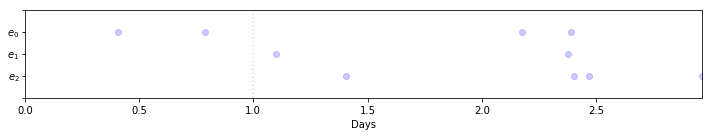

In [5]:
# Multivariate example

m = np.array([0.8, 0.0, 0.0]) # Number of events per timestamp each class (three in this case) ---> lambda, Background intensity
a = np.array([[0.1, 0.0, 0.0],   # Vector matrix of initialintensity ---> alpha
              [0.9, 0.0, 0.0],    # Jump in intensity after arrival.
              [0.0, 0.9, 0.0]])
w = 3.1 # time lag ----> beta, Decay rate  (sarebbe il learning rate?!)
tau = 3 # Time interval

P = MHP(mu=m, alpha=a, omega=w)
P.generate_seq(tau)
P.plot_events()


In [6]:
print(P.check_stability())


Max eigenvalue: 0.10000
None


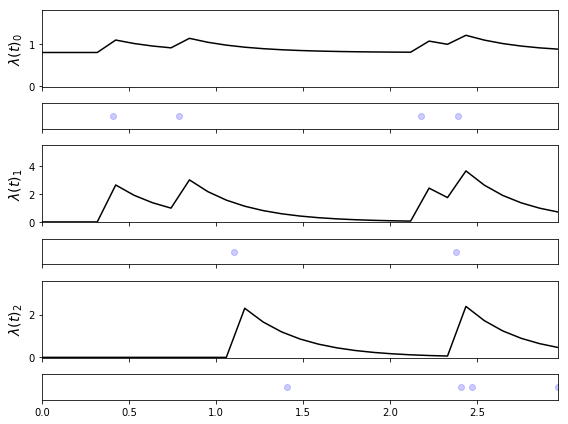

In [7]:
P.plot_rates()

In [8]:
P.get_rate(3, 0)

0.8708682885371162

In [ ]:
mhat = np.random.uniform(0,1, size=3)
ahat = np.random.uniform(0,1, size=(3,3))
w = 3.

P.EM(ahat, mhat, w)

In [ ]:
# Multivariate example

m = np.array([0.8, 0.0, 0.0]) #  3 TOPICS
a = np.array([[1, 1, 2],   # intensità lambda - NUMERO DI DOCUMENTI PER TOPIC
              [1, 5, 1],    
              [4, 7, 5]])
w = 3.1 # time lag ----> beta, Decay rate  (sarebbe il learning rate?!)
tau = 3 # NUMERO DI INTERVALLI

P = MHP(mu=m, alpha=a, omega=w)
P.generate_seq(tau)
P.plot_events()


In [ ]:
P.plot_rates()